Data extraction and plotting: Witmotion Sensor

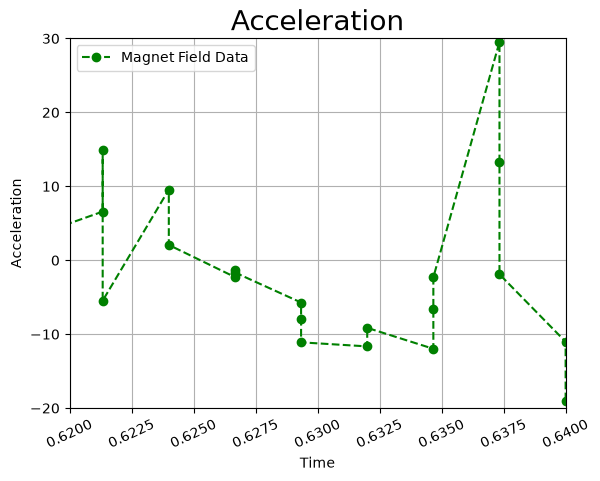

In [2]:

import matplotlib.pyplot as plt
import csv
from datetime import datetime
import numpy as np

x = []
y = []

start_time = 0

start = 2795
limit = 42
count = 0

with open('swinging springs calibration sypt 2026.csv', 'r') as csvfile:
    lines = csv.reader(csvfile, delimiter=',')
    for i, row in enumerate(lines):
        if i <= start or i >= (start+limit):
            continue

        try:
            t = datetime.strptime(row[0].strip(), "%H:%M:%S.%f")

            # Convert to seconds
            time_seconds = (
                t.hour * 3600 +
                t.minute * 60 +
                t.second +
                t.microsecond / 1_000_000
            )

            if start_time == 0:
                start_time = time_seconds

            time_seconds = (time_seconds - start_time) * (8/3) + 0.6

            acceleration_time = ((float(row[4]))-1)*9.81
        except (ValueError, IndexError):
            continue

        if time_seconds == 0:
            continue


        x.append(time_seconds)
        y.append(acceleration_time)
        count += 1


plt.plot(
    x,
    y,
    color='g',
    linestyle='dashed',
    marker='o',
    label='Magnet Field Data'
)

plt.xlim([0.62,0.64])
plt.ylim([-20,30])

plt.xticks(rotation=25)
plt.xlabel('Time')
plt.ylabel('Acceleration')
plt.title('Acceleration', fontsize=20)
plt.grid()
plt.legend()
plt.show()

Major jerk at: 0.6373333333215365 seconds
Jerk: 11937.543790996864 g/s


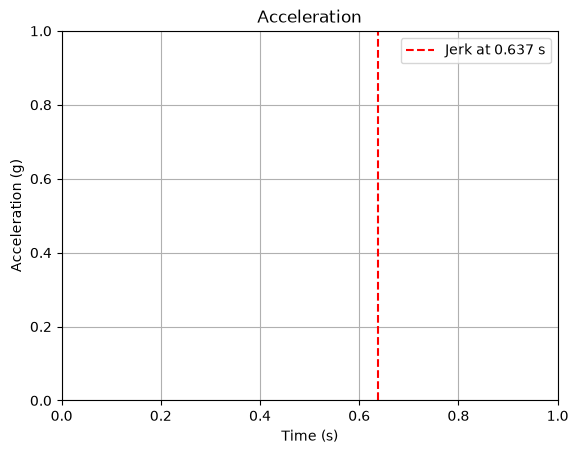

In [3]:
jerk = []
jerk_time = []

for i in range(1, len(y)):
    dt = x[i] - x[i-1]

    if dt != 0:
        j = (y[i] - y[i-1]) / dt
        jerk.append(j)
        jerk_time.append(x[i])

max_jerk = 0
max_jerk_time = 0

for t, j in zip(jerk_time, jerk):
    if t < 12.13 and abs(j) > abs(max_jerk):
        max_jerk = j
        max_jerk_time = t

print("Major jerk at:", max_jerk_time, "seconds")
print("Jerk:", max_jerk, "g/s")

plt.axvline(
    max_jerk_time,
    color='r',
    linestyle='--',
    label=f'Jerk at {max_jerk_time:.3f} s'
)

plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.title('Acceleration')
plt.grid()
plt.legend()
plt.show()

Points used for fitting:
t = 0.620 s, x = 0.012 m
t = 0.620 s, x = 0.024 m
t = 0.620 s, x = 0.036 m
t = 0.650 s, x = 0.060 m
t = 0.650 s, x = 0.072 m
t = 0.650 s, x = 0.084 m
t = 0.640 s, x = 0.096 m
t = 0.640 s, x = 0.108 m

Sine fit parameters:
A = -1.132788 m
B = 20.238780 rad/s
C = -8.210168 rad
D = -1.030269 m

Frequency = 3.2211 Hz
Period = 0.3105 s


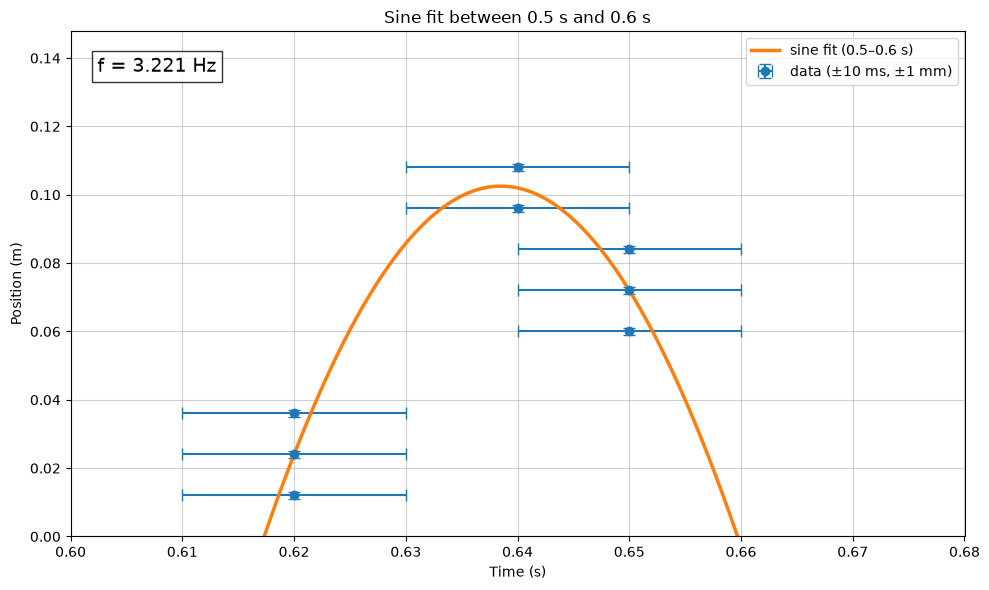

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# SETTINGS
# ============================================================

filename = "CA1_R1.CSV"

dt = 0.01

positions = np.array([
    0.000,
    0.012,
    0.024,
    0.036,
    0.048,
    0.060,
    0.072,
    0.084,
    0.096,
    0.108
])

time_error = 0.010
position_error = 0.001

sensor_columns = [
    "M0", "M1", "M2", "M3", "M4",
    "M5", "M6", "M7", "M8", "M9"
]

# ============================================================
# READ CSV
# ============================================================

df = pd.read_csv(filename)

# ============================================================
# FIND TRIGGER TIME FOR EACH SENSOR
# ============================================================

trigger_times = []

for sensor in sensor_columns:

    values = df[sensor].values

    change = np.abs(np.diff(values))

    trigger_index = np.argmax(change) + 1

    trigger_time = trigger_index * dt

    trigger_times.append(trigger_time)

trigger_times = np.array(trigger_times)

# ============================================================
# REMOVE INVALID POINTS
# ============================================================

valid = np.isfinite(trigger_times)

t = trigger_times[valid]
x = positions[valid]

# ============================================================
# SET FIRST DETECTION TO t = 0
# AND MAKE TIME POSITIVE
# ============================================================

t = np.abs(t - t[0])

# ============================================================
# ONLY USE DATA BETWEEN 0.5 AND 0.6 s FOR FITTING
# ============================================================

fit_mask = (t >= 0.6) & (t <= 0.7)

t_selected = t[fit_mask]
x_selected = x[fit_mask]

print("Points used for fitting:")
for ti, xi in zip(t_selected, x_selected):
    print(f"t = {ti:.3f} s, x = {xi:.3f} m")

# ============================================================
# CHECK THAT ENOUGH POINTS EXIST
# ============================================================

if len(t_selected) < 4:
    raise ValueError(
        f"Only {len(t_selected)} points found between 0.5 and 0.6 s. "
        "A sine fit with 4 parameters needs at least 4 points."
    )

# ============================================================
# SINE FIT
#
# x(t) = A*sin(B*t + C) + D
#
# A = amplitude
# B = angular frequency
# C = phase
# D = vertical offset
# ============================================================

def sine_function(t, A, B, C, D):
    return A * np.sin(B * t + C) + D

# ============================================================
# INITIAL GUESSES
# ============================================================

A_guess = (x_selected.max() - x_selected.min()) / 2

D_guess = np.mean(x_selected)

B_guess = 5

C_guess = 0

p0 = [
    A_guess,
    B_guess,
    C_guess,
    D_guess
]

# ============================================================
# FIT ONLY THE SELECTED REGION
# ============================================================

parameters, covariance = curve_fit(
    sine_function,
    t_selected,
    x_selected,
    p0=p0,
    maxfev=10000
)

A, B, C, D = parameters

# ============================================================
# PRINT FIT PARAMETERS
# ============================================================

print()
print("Sine fit parameters:")
print(f"A = {A:.6f} m")
print(f"B = {B:.6f} rad/s")
print(f"C = {C:.6f} rad")
print(f"D = {D:.6f} m")

# Frequency
frequency = abs(B) / (2 * np.pi)

# Period
period = 2 * np.pi / abs(B)

print()
print(f"Frequency = {frequency:.4f} Hz")
print(f"Period = {period:.4f} s")

# ============================================================
# CREATE SMOOTH FIT CURVE
# ONLY BETWEEN 0.5 AND 0.6 s
# ============================================================

t_fit = np.linspace(
    0.6,
    0.7,
    500
)

y_fit = sine_function(
    t_fit,
    A,
    B,
    C,
    D
)

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(10, 6))

# Plot ALL measured points
plt.errorbar(
    t,
    x,
    xerr=time_error,
    yerr=position_error,
    fmt='o',
    capsize=4,
    label='data (±10 ms, ±1 mm)'
)

# Plot sine fit only from 0.5 to 0.6 s
plt.plot(
    t_fit,
    y_fit,
    linewidth=2.5,
    label='sine fit (0.5–0.6 s)'
)

# ============================================================
# DISPLAY FREQUENCY
# ============================================================

plt.text(
    0.03,
    0.92,
    f'f = {frequency:.3f} Hz',
    transform=plt.gca().transAxes,
    fontsize=14,
    bbox=dict(facecolor='white', alpha=0.8)
)

# ============================================================
# FORMATTING
# ============================================================

plt.xlabel("Time (s)")
plt.ylabel("Position (m)")

plt.title("Sine fit between 0.5 s and 0.6 s")

plt.ylim(bottom=0)
plt.xlim(left=0.6)
plt.xlim(right=0.68)

plt.grid(True, alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()

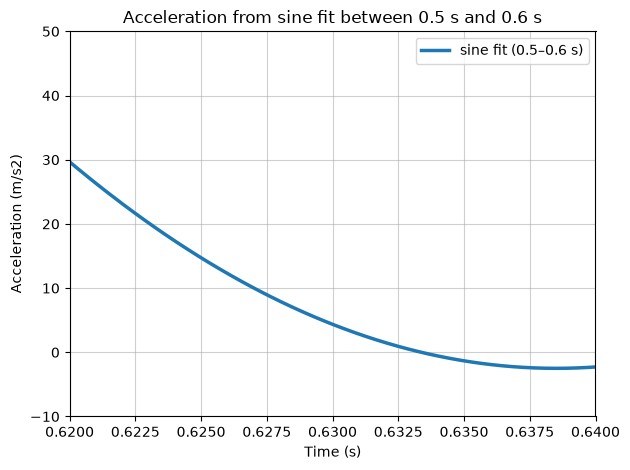

In [5]:
import numpy as np

v_fit = np.gradient(y_fit, t_fit)
a_fit = np.gradient(v_fit, t_fit)

a_fit = a_fit + 461.5

# Plot sine fit only from 0.5 to 0.6 s
plt.plot(
    t_fit,
    a_fit,
    linewidth=2.5,
    label='sine fit (0.5–0.6 s)'
)


plt.xlim([0.62,0.64])
plt.ylim([-10,50])

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s2)")

plt.title("Acceleration from sine fit between 0.5 s and 0.6 s")


plt.grid(True, alpha=0.6)

plt.legend()

plt.tight_layout()

plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt

A1, B1, C1, D1 = parameters
A2, omega2, t_peak2, C2 = params

def f1(t):
    return (
        -A1 * B1**2 * np.sin(B1 * t + C1)
        + 461.5
    )

def f2(t):
    return (
        A2 * np.cos(
            omega2 * (t - t_peak2)
        )
        + C2
    )

t_common = np.linspace(
    0.620,
    0.640,
    2000
)

f1_values = f1(t_common)
f2_values = f2(t_common)

mask = (
    (f1_values >= 0)
    &
    (f1_values <= 1)
)

z_cal = f1_values[mask]
target_cal = f2_values[mask]

degree = 3

coefficients = np.polyfit(
    z_cal,
    target_cal,
    degree
)

g = np.poly1d(coefficients)

mapped_cal = g(z_cal)

residuals = (
    target_cal
    - mapped_cal
)

ss_res = np.sum(
    residuals**2
)

ss_tot = np.sum(
    (
        target_cal
        - np.mean(target_cal)
    )**2
)

R_squared = (
    1
    - ss_res / ss_tot
)

RMSE = np.sqrt(
    np.mean(
        residuals**2
    )
)

NRMSE = (
    RMSE
    /
    (
        np.max(target_cal)
        - np.min(target_cal)
    )
    * 100
)

print(
    "Number of calibration points:",
    len(z_cal)
)

print()

print(
    "IR range:",
    np.min(z_cal),
    "to",
    np.max(z_cal)
)

print()

print(
    "WitMotion range:",
    np.min(target_cal),
    "to",
    np.max(target_cal)
)

print()

print("g(z) =")
print(g)

print()

print(
    "R² =",
    R_squared
)

print(
    "RMSE =",
    RMSE,
    "m/s²"
)

print(
    "NRMSE =",
    NRMSE,
    "%"
)

print()

print(
    "g(0.5) =",
    g(0.5),
    "m/s²"
)

z_plot = np.linspace(
    0,
    1,
    1000
)

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    z_cal,
    target_cal,
    s=20,
    label="f1(t) → f2(t)"
)

plt.plot(
    z_plot,
    g(z_plot),
    linewidth=2.5,
    label="Cubic mapping g(z)"
)

plt.xlabel(
    "IR acceleration (m/s²)"
)

plt.ylabel(
    "WitMotion acceleration (m/s²)"
)

plt.title(
    "IR → WitMotion acceleration mapping"
)

plt.xlim(
    0,
    1
)

plt.grid(
    True,
    alpha=0.6
)

plt.legend()
plt.tight_layout()
plt.show()

TypeError: expected non-empty vector for x